The aim of this study is to investigate the factors influencing the salaries of Data Scientists.

To conduct this analysis, a dataset containing relevant information about Data Scientists was used. The dataset includes the following variables:

*   work_year:The year the salary was paid.
*   experience_level: The experience level in the job during the year (EN > Entry-level / Junior, MI> Mid-level / Intermediate, SE > Senior-level / Expert, EX > Executive-level / Director).
*   employment_type: The type of employment for the role (PT > Part-time, FT > Full-time, CT > Contract, FL > Freelance).
*   job_title: The role worked in during the year.
*   salary: The total gross salary amount paid.
*   salary_currency: The currency of the salary paid as an ISO 4217 currency code.
*   salaryinusd: The salary in USD.
*   employee_residence: Employee's primary country of residence during the work year as an ISO 3166 country code.
*   remote_ratio:The overall amount of work done remotely.
*   company_location: The country of the employer's main office or contracting branch.
*   company_size: The median number of people that worked for the company during the year.

**PREGUNTA 1 (1 pto.): ¿Hay algún atributo o atributos que ya desecharías? Razónalo y elimínalo del dataset**

In [ ]:
import pandas as pd
import numpy as np
from google.colab import drive

drive.mount('/content/drive')

df = pd.read_csv('/content/drive/MyDrive/Datasets/SAA/salaries.csv')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
df.head()

,work_year,experience_level,employment_type,job_title,salary,salary_currency,salary_in_usd,employee_residence,remote_ratio,company_location,company_size
0,2023,SE,FT,Principal Data Scientist,80000,EUR,85847,ES,100,ES,L
1,2023,MI,CT,ML Engineer,30000,USD,30000,US,100,US,S
2,2023,MI,CT,ML Engineer,25500,USD,25500,US,100,US,S
3,2023,SE,FT,Data Scientist,175000,USD,175000,CA,100,CA,M
4,2023,SE,FT,Data Scientist,120000,USD,120000,CA,100,CA,M


In [ ]:
# Yo quitaría salary y salary_currency

# El dataset ya incluye una columna llamada salary_in_usd.
# Esta columna es una transformación de salary utilizando el tipo de cambio de la moneda (salary_currency) en ese momento

In [ ]:
df = df.drop(['salary', 'salary_currency'], axis=1)
display(df.head())

,work_year,experience_level,employment_type,job_title,salary_in_usd,employee_residence,remote_ratio,company_location,company_size
0,2023,SE,FT,Principal Data Scientist,85847,ES,100,ES,L
1,2023,MI,CT,ML Engineer,30000,US,100,US,S
2,2023,MI,CT,ML Engineer,25500,US,100,US,S
3,2023,SE,FT,Data Scientist,175000,CA,100,CA,M
4,2023,SE,FT,Data Scientist,120000,CA,100,CA,M


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3755 entries, 0 to 3754
Data columns (total 11 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   work_year           3755 non-null   int64 
 1   experience_level    3755 non-null   object
 2   employment_type     3755 non-null   object
 3   job_title           3755 non-null   object
 4   salary              3755 non-null   int64 
 5   salary_currency     3755 non-null   object
 6   salary_in_usd       3755 non-null   int64 
 7   employee_residence  3755 non-null   object
 8   remote_ratio        3755 non-null   int64 
 9   company_location    3755 non-null   object
 10  company_size        3755 non-null   object
dtypes: int64(4), object(7)
memory usage: 322.8+ KB


# **PREPARACIÓN DE DATOS**

In [ ]:
df['work_year'].unique()

array([2023, 2022, 2020, 2021])

In [ ]:
df['work_year'] = df['work_year'].map({2020: 0, 2021: 1, 2022:2, 2023:3})
df['work_year'].unique()

array([3, 2, 0, 1])

In [ ]:
df['experience_level']=df['experience_level'].map({'EN': 0, 'MI': 1, 'SE': 2, 'EX':3})
df['experience_level'].unique()

array([2, 1, 0, 3])

In [ ]:
from sklearn.preprocessing import OneHotEncoder

df['employment_type'].unique()

array(['FT', 'CT', 'FL', 'PT'], dtype=object)

**PREGUNTA 2 (1 pto.): APLICA ONE-HOT ENCODING A employment_type, employee_residence Y A compay_location**

In [ ]:
df['job_title'].unique()

array(['Principal Data Scientist', 'ML Engineer', 'Data Scientist',
       'Applied Scientist', 'Data Analyst', 'Data Modeler',
       'Research Engineer', 'Analytics Engineer',
       'Business Intelligence Engineer', 'Machine Learning Engineer',
       'Data Strategist', 'Data Engineer', 'Computer Vision Engineer',
       'Data Quality Analyst', 'Compliance Data Analyst',
       'Data Architect', 'Applied Machine Learning Engineer',
       'AI Developer', 'Research Scientist', 'Data Analytics Manager',
       'Business Data Analyst', 'Applied Data Scientist',
       'Staff Data Analyst', 'ETL Engineer', 'Data DevOps Engineer',
       'Head of Data', 'Data Science Manager', 'Data Manager',
       'Machine Learning Researcher', 'Big Data Engineer',
       'Data Specialist', 'Lead Data Analyst', 'BI Data Engineer',
       'Director of Data Science', 'Machine Learning Scientist',
       'MLOps Engineer', 'AI Scientist', 'Autonomous Vehicle Technician',
       'Applied Machine Learning Sc

In [ ]:
df['job_title']=df['job_title'].astype('category').cat.codes
df['job_title'].unique()

array([84, 66, 47,  8, 25, 38, 88,  4, 18, 69, 50, 33, 23, 41, 22, 31,  6,
        1, 89, 29, 17,  5, 91, 55, 32, 58, 45, 37, 73, 16, 49, 62, 13, 53,
       74, 67,  3,  9,  7, 64, 21, 57, 34, 90,  2, 40, 14, 44, 52, 11, 42,
       30, 70, 12, 59, 61, 51, 75, 15, 86, 24, 10, 78, 28, 35, 43, 72, 79,
       76, 68,  0, 85, 27, 26, 36, 46, 48, 20, 39, 77, 80, 87, 82, 71, 65,
       54, 19, 63, 60, 81, 83, 92, 56], dtype=int8)

In [ ]:
df['company_size']=df['company_size'].map({'S': 0, 'M': 1, 'L': 2})
df['company_size'].unique()

array([2, 0, 1])

In [ ]:
# Apply One-Hot Encoding to the specified columns
# Using pd.get_dummies
df_encoded = pd.get_dummies(df, columns=['employment_type', 'employee_residence', 'company_location'])

**PREGUNTA 3 (1 pto.): ¿HAY ALGUNA VARIABLE QUE TENGA OUTLIERS? ¿CÓMO LO SOLUCIONARÍAS? JUSTIFICA LA RESPUESTA**

Límite superior para outliers: 295000.00 USD
Número de outliers detectados: 63


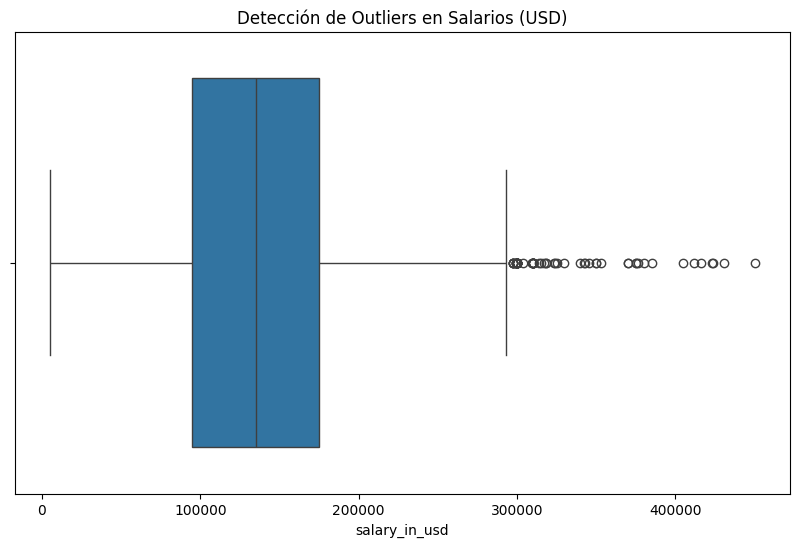

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Identificación matemática (IQR) para 'salary_in_usd'
Q1 = df['salary_in_usd'].quantile(0.25)
Q3 = df['salary_in_usd'].quantile(0.75)
IQR = Q3 - Q1

# Definir límites
limite_inferior = Q1 - 1.5 * IQR
limite_superior = Q3 + 1.5 * IQR

# Filtrar outliers
outliers = df[(df['salary_in_usd'] < limite_inferior) | (df['salary_in_usd'] > limite_superior)]

print(f"Límite superior para outliers: {limite_superior:.2f} USD")
print(f"Número de outliers detectados: {len(outliers)}")

# 2. Visualización
plt.figure(figsize=(10, 6))
sns.boxplot(x=df['salary_in_usd'])
plt.title('Detección de Outliers en Salarios (USD)')
plt.show()

In [ ]:
# He elegido identificar salary_in_usd porque es la variable con mayor variabilidad.
# Los outliers aquí suelen representar roles muy especializados o empresas "Big Tech".
# No los eliminaría directamente porque son datos verídicos; en su lugar, usaría la transformación logarítmica para normalizar la distribución y mejorar la convergencia de algoritmos estadísticos

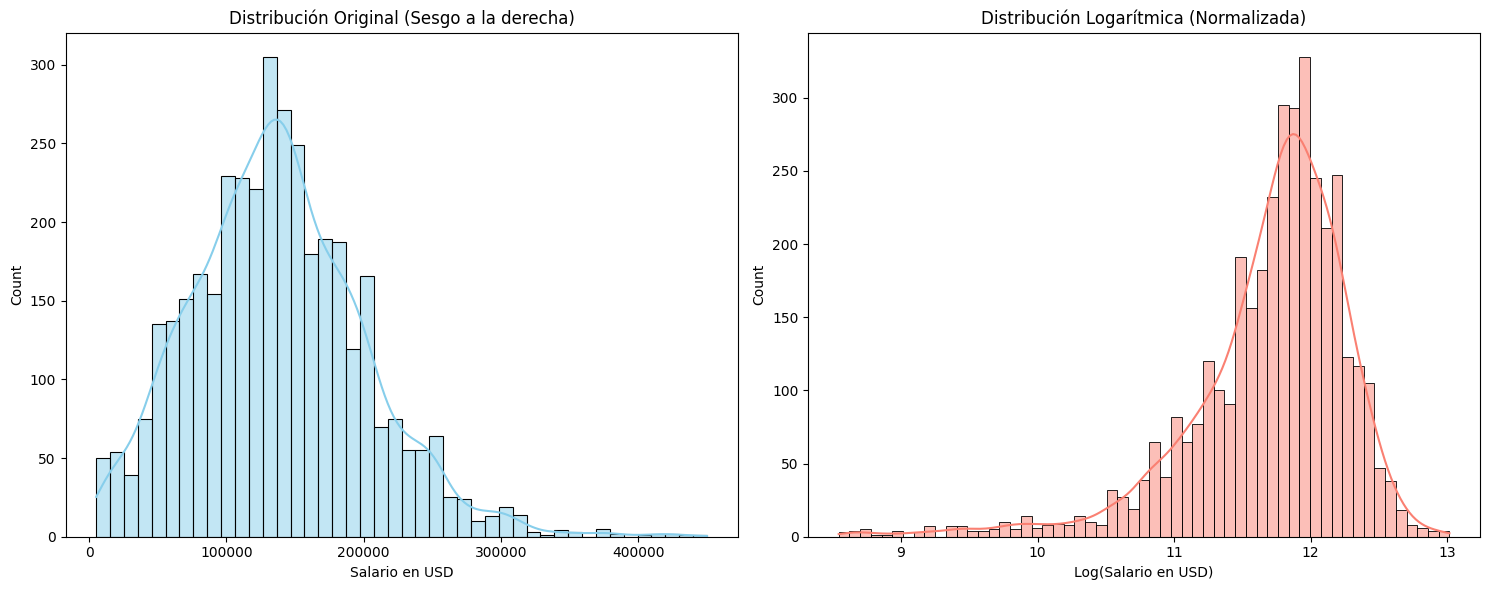

In [ ]:
# Aplicar la transformación logarítmica
# Usamos np.log1p (log(1+x)) por seguridad, aunque los salarios son > 0
df['log_salary_in_usd'] = np.log1p(df['salary_in_usd'])

# Configurar la visualización para comparar
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Histograma Original
sns.histplot(df['salary_in_usd'], kde=True, ax=axes[0], color='skyblue')
axes[0].set_title('Distribución Original (Sesgo a la derecha)')
axes[0].set_xlabel('Salario en USD')

# Histograma Logarítmico
sns.histplot(df['log_salary_in_usd'], kde=True, ax=axes[1], color='salmon')
axes[1].set_title('Distribución Logarítmica (Normalizada)')
axes[1].set_xlabel('Log(Salario en USD)')

plt.tight_layout()
plt.show()

# **REDUCCIÓN DIMENSIONALIDAD**

**PREGUNTA 4 (2 PTOS.): APLICA CORRELACIÓN PARA REDUCIR LA DIMENSIONALIDAD**

In [ ]:
# 1. Preparar el dataset (asegurarnos de que todo sea numérico)
# Convertimos las columnas restantes (experience_level, company_size) a códigos numéricos
df_numeric = df_encoded.copy()
df_numeric['experience_level'] = df_numeric['experience_level'].astype('category').cat.codes
df_numeric['company_size'] = df_numeric['company_size'].astype('category').cat.codes
# Excluimos 'job_title' por ahora por su alta cardinalidad
df_numeric = df_numeric.drop(columns=['job_title'])

# 2. Calcular la matriz de correlación
corr_matrix = df_numeric.corr().abs()

# 3. Seleccionar el triángulo superior de la matriz (para no repetir pares)
upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))

# 4. Identificar columnas con correlación superior a 0.85
to_drop = [column for column in upper.columns if any(upper[column] > 0.85)]

print(f"Columnas a eliminar por alta correlación (>0.85): {to_drop}")

# 5. Eliminar las columnas
df_reduced = df_numeric.drop(columns=to_drop)

print(f"Dimensiones originales: {df_numeric.shape[1]}")
print(f"Dimensiones tras reducción: {df_reduced.shape[1]}")

Columnas a eliminar por alta correlación (>0.85): ['company_location_AE', 'company_location_AM', 'company_location_BA', 'company_location_BE', 'company_location_BR', 'company_location_CA', 'company_location_CF', 'company_location_CH', 'company_location_CN', 'company_location_CO', 'company_location_DE', 'company_location_DK', 'company_location_DZ', 'company_location_EG', 'company_location_ES', 'company_location_FR', 'company_location_GB', 'company_location_GH', 'company_location_GR', 'company_location_HN', 'company_location_HR', 'company_location_IE', 'company_location_IN', 'company_location_IQ', 'company_location_IR', 'company_location_JP', 'company_location_KE', 'company_location_LT', 'company_location_LV', 'company_location_MA', 'company_location_MD', 'company_location_MK', 'company_location_MT', 'company_location_MX', 'company_location_NL', 'company_location_NZ', 'company_location_PR', 'company_location_PT', 'company_location_SE', 'company_location_SI', 'company_location_SK', 'compa

In [ ]:
# Al eliminar variables redundantes, reducimos la complejidad del modelo (evitando el overfitting), disminuimos el tiempo de cómputo
# y resolvemos problemas de inestabilidad numérica en modelos lineales causados por la multicolinealidad.

# **APRENDIZAJE SUPERVISADO**

**PREGUNTA 5 (1 PTO.): La variable objetivo será salary_in_usd. ¿Es un problema de clasificación o de regresión? Justifícalo**

In [ ]:
# Es un  problema de regresión ya que tratamos de precedir el salario con diferentes carácteristicas,
# luego el resultado esperado es un valor númerico -> REGRESIÓN

## **SVM**

**PREGUNTA 6 (3 PTOS.): APLICA SVM SIN NORMALIZAR (1 PTO.), Y LUEGO NORMALIZANDO (1 PTO.) Y COMPARA LOS RESULTADOS, ¿QUÉ MÉTRICAS USARÍAS? (1 PTO.)**

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.svm import SVR
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [ ]:
# Simplificamos: One-hot para categorías básicas y eliminamos columnas redundantes
df_ml = pd.read_csv('/content/drive/MyDrive/Datasets/SAA/salaries.csv')

df_ml = pd.get_dummies(df_ml.drop(columns=['salary', 'salary_currency', 'job_title']), drop_first=True)

X = df_ml.drop(columns=['salary_in_usd'])
y = df_ml['salary_in_usd']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# --- MODELO A: SVM SIN NORMALIZAR ---
svr_raw = SVR(kernel='rbf')
svr_raw.fit(X_train, y_train)
y_pred_raw = svr_raw.predict(X_test)

In [ ]:
# --- MODELO B: SVM CON NORMALIZACIÓN ---
scaler_X = StandardScaler()
scaler_y = StandardScaler()

X_train_scaled = scaler_X.fit_transform(X_train)
X_test_scaled = scaler_X.transform(X_test)

# SVR es muy sensible al rango de 'y' también
y_train_scaled = scaler_y.fit_transform(y_train.values.reshape(-1, 1)).flatten()

svr_scaled = SVR(kernel='rbf')
svr_scaled.fit(X_train_scaled, y_train_scaled)
y_pred_scaled_norm = svr_scaled.predict(X_test_scaled)

# Des-normalizamos la predicción para comparar en escala real (USD)
y_pred_scaled = scaler_y.inverse_transform(y_pred_scaled_norm.reshape(-1, 1)).flatten()

In [ ]:
# 2. Funciones de Evaluación
def evaluate(y_true, y_pred, label):
    print(f"--- Métricas {label} ---")
    print(f"MAE:  {mean_absolute_error(y_true, y_pred):.2f}")
    print(f"RMSE: {np.sqrt(mean_squared_error(y_true, y_pred)):.2f}")
    print(f"R2:   {r2_score(y_true, y_pred):.4f}\n")

evaluate(y_test, y_pred_raw, "SIN NORMALIZAR")
evaluate(y_test, y_pred_scaled, "NORMALIZANDO")

--- Métricas SIN NORMALIZAR ---
MAE:  48559.38
RMSE: 62834.57
R2:   -0.0001

--- Métricas NORMALIZANDO ---
MAE:  37867.92
RMSE: 50500.22
R2:   0.3540



Para este problema de regresión de salarios, las métricas más adecuadas son:

    MAE (Mean Absolute Error): Es la más fácil de interpretar. Nos dice, en promedio, cuántos dólares de diferencia hay entre la predicción y el salario real. Si el MAE es 20,000, el modelo se equivoca en esa cantidad promedio.

    RMSE (Root Mean Squared Error): A diferencia del MAE, esta métrica penaliza más los errores grandes. En salarios, es útil para detectar si el modelo falla estrepitosamente en sueldos muy altos (ejutivos).

    R2 (Coeficiente de Determinación): Indica qué porcentaje de la variabilidad de los salarios es explicada por el modelo. Un R2=0.70 significaría que el modelo explica el 70% de las variaciones salariales.

## **ÀRBOLES DE DECISIÓN**

**PREGUNTA 7 (1 PTO.): APLICA ÁRBOLES DE DECISIÓN. ¿ES NECESARIO NORMALIZAR?**

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_absolute_error, r2_score

# Cargar y preparar datos (mismo preprocesamiento básico de categorías)
df_tree = pd.read_csv('/content/drive/MyDrive/Datasets/SAA/salaries.csv')
df_tree = pd.get_dummies(df_tree.drop(columns=['salary', 'salary_currency', 'job_title']), drop_first=True)

X = df_tree.drop(columns=['salary_in_usd'])
y = df_tree['salary_in_usd']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Entrenar el modelo de Árbol de Decisión
# No aplicamos StandardScaler ni ningún tipo de normalización
dt_model = DecisionTreeRegressor(random_state=42, max_depth=10)
dt_model.fit(X_train, y_train)

# Predicción y Evaluación
y_pred = dt_model.predict(X_test)

print(f"MAE: {mean_absolute_error(y_test, y_pred):.2f}")
print(f"R2 Score: {r2_score(y_test, y_pred):.4f}")

MAE: 39885.27
R2 Score: 0.3184


In [ ]:
# No, no es necesario. A diferencia de los modelos basados en distancias (como SVM o KNN) o
# en descenso de gradiente (como la Regresión Lineal), los Árboles de Decisión son invariantes a la escala de los datos.

In [ ]:
# Aunque normalizar no perjudica al modelo, es un paso innecesario que consume recursos computacionales en modelos de árboles.
# Esto los hace muy atractivos para trabajar con datasets que tienen variables en escalas muy dispares